# Quantum approximate optimization algorithm

## Setup



In [8]:
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.transpiler import CouplingMap
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator

In [3]:
import networkx as nx
import rustworkx as rx
import numpy as np
import matplotlib.pyplot as plt

def generate_deterministic_graph(n, degree=3, seed=42):
    """
    Generates a random regular graph (nodes have fixed number of connections).
    
    Args:
        n (int): Number of nodes
        degree (int): Number of edges per node (3 is standard for MaxCut benchmarks)
        seed (int): Seed for reproducibility
        
    Returns:
        rx.PyGraph: The graph ready for your pipeline
    """
    # 1. Use NetworkX to generate the structure (it has great generators)
    # 'random_regular_graph' creates a graph where every node has 'd' neighbors
    # This is much more realistic for QAOA than a complete graph.
    G_nx = nx.random_regular_graph(d=degree, n=n, seed=seed)

    # 2. Convert to Rustworkx (rx.PyGraph)
    graph_rx = rx.PyGraph()
    graph_rx.add_nodes_from(np.arange(0, n, 1))

    # 3. Add edges with weight 1.0
    # format: (start_node, end_node, weight)
    weighted_edges = [(u, v, 1.0) for u, v in G_nx.edges()]
    graph_rx.add_edges_from(weighted_edges)

    return graph_rx


Cost Function Hamiltonian: SparsePauliOp(['IIZIIIIIIZ', 'IIIIIIZIIZ', 'IIIZIIIIIZ', 'IIIIZIIIZI', 'IIIIIIZIZI', 'ZIIIIIIIZI', 'IIIZIIIZII', 'IIIIZIIZII', 'IZIIIIIZII', 'IIIIIZZIII', 'ZIIIIZIIII', 'IZIIIZIIII', 'ZIIIZIIIII', 'IIZZIIIIII', 'IZZIIIIIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -6.836163836163837
       x: [ 1.120e+00  1.396e+00  4.470e+00  2.661e+00]
    nfev: 34
   maxcv: 0.0


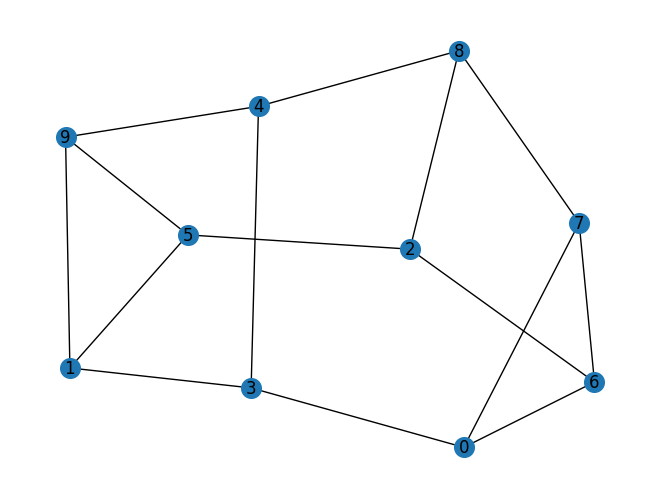

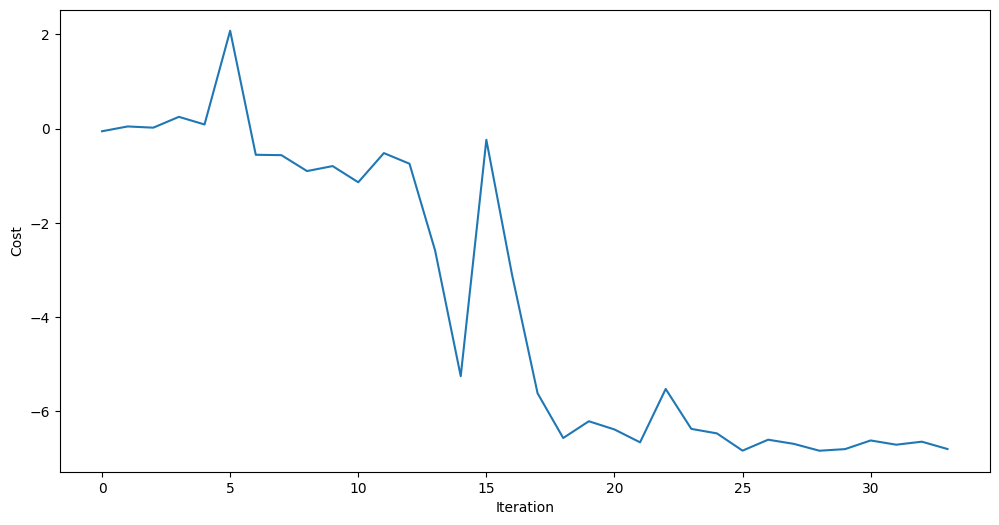

{533: 0.0043, 360: 0.0191, 150: 0.017, 873: 0.0133, 362: 0.0085, 653: 0.0086, 844: 0.0078, 609: 0.0002, 726: 0.0039, 663: 0.0166, 371: 0.0394, 159: 0.001, 783: 0.0024, 263: 0.003, 840: 0.0159, 588: 0.0029, 151: 0.0418, 426: 0.0013, 339: 0.008, 781: 0.0157, 183: 0.0166, 188: 0.0165, 424: 0.0032, 872: 0.0423, 835: 0.0167, 557: 0.0009, 174: 0.0005, 291: 0.0025, 898: 0.0004, 936: 0.008, 83: 0.0019, 394: 0.0003, 49: 0.001, 661: 0.0085, 813: 0.0029, 206: 0.0004, 732: 0.0038, 809: 0.009, 924: 0.0004, 181: 0.0079, 252: 0.0034, 941: 0.0014, 23: 0.0184, 82: 0.0011, 652: 0.0412, 55: 0.0026, 113: 0.0031, 297: 0.0039, 1000: 0.0157, 305: 0.003, 764: 0.0009, 842: 0.0094, 655: 0.0021, 524: 0.0005, 361: 0.0028, 246: 0.0009, 775: 0.0196, 701: 0.0012, 184: 0.0022, 654: 0.0095, 801: 0.0038, 177: 0.0032, 307: 0.0094, 248: 0.0198, 279: 0.0074, 210: 0.0038, 458: 0.0012, 343: 0.0015, 680: 0.0028, 488: 0.0051, 641: 0.0001, 834: 0.0031, 662: 0.0036, 296: 0.0004, 179: 0.0078, 503: 0.0003, 222: 0.0034, 716: 0.009

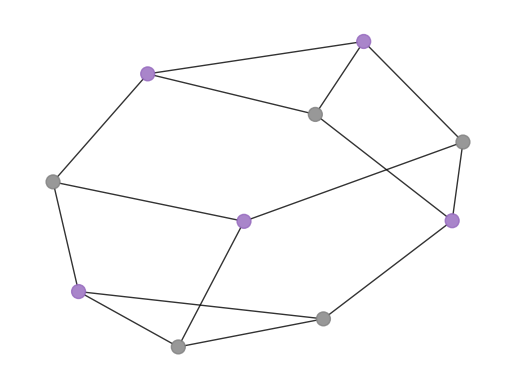

In [4]:
n = 10

# Generate the graph
graph = generate_deterministic_graph(n)

draw_graph(graph, node_size=200, with_labels=True, width=1)


def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

# Build the circuit - automatic!
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw("mpl")

circuit.parameters

# Simulator of the circuit
aer_sim = AerSimulator()
backend = aer_sim
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

objective_func_vals = []  # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

'''matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()'''

# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )


plot_result(graph, most_likely_bitstring)

def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(
        list(graph.nodes())
    ), "The length of x must coincide with the number of nodes in the graph."
    return sum(
        x[u] * (1 - x[v]) + x[v] * (1 - x[u])
        for u, v in list(graph.edge_list())
    )


cut_value = evaluate_sample(most_likely_bitstring, graph)
print("The value of the cut is:", cut_value)

Cost Function Hamiltonian: SparsePauliOp(['IZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZI', 'IIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIZIIII', 'IIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIII

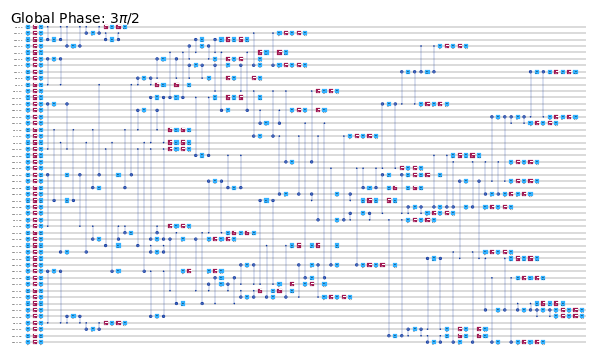

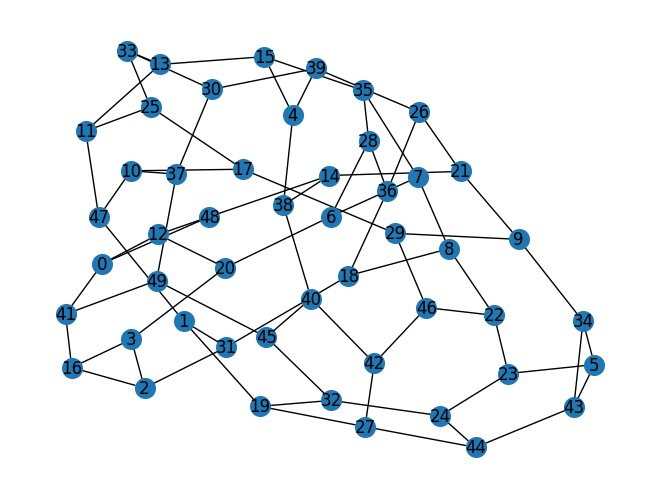

In [5]:
n = 50

# Generate the graph
graph = generate_deterministic_graph(n)

draw_graph(graph, node_size=200, with_labels=True, width=1)

max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

# Build the circuit - automatic!
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=1)
#circuit.measure_all()

circuit.draw("mpl", fold=False, scale=0.2, idle_wires=False)

circuit.parameters

cmap = CouplingMap.from_full(n)

# 3. Initialize the simulator with this map
aer_sim = AerSimulator(coupling_map=cmap)
backend = aer_sim
basis_gates = ['cx', 'id', 'rz', 'sx', 'x']

# 4. Generate the Pass Manager
# CRITICAL: We pass 'coupling_map' and 'basis_gates' directly. 
# We do NOT pass 'backend=backend', because that would re-introduce the problematic 'ccx'.
pm = generate_preset_pass_manager(
    optimization_level=3,
    coupling_map=cmap,
    basis_gates=basis_gates
)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, scale=0.1, idle_wires=False)

# Create random parameters (instead of optimizing them)
# This takes 0.001 seconds vs 10+ minutes
num_params = candidate_circuit.num_parameters
random_params = np.random.uniform(0, 2 * np.pi, num_params)

# Bind them to the circuit to make it "runnable"
optimized_circuit = candidate_circuit.assign_parameters(random_params)

print("Circuit generated with random parameters (Optimization skipped).")

optimized_circuit.draw("mpl", fold=False, scale=0.1, idle_wires=False)

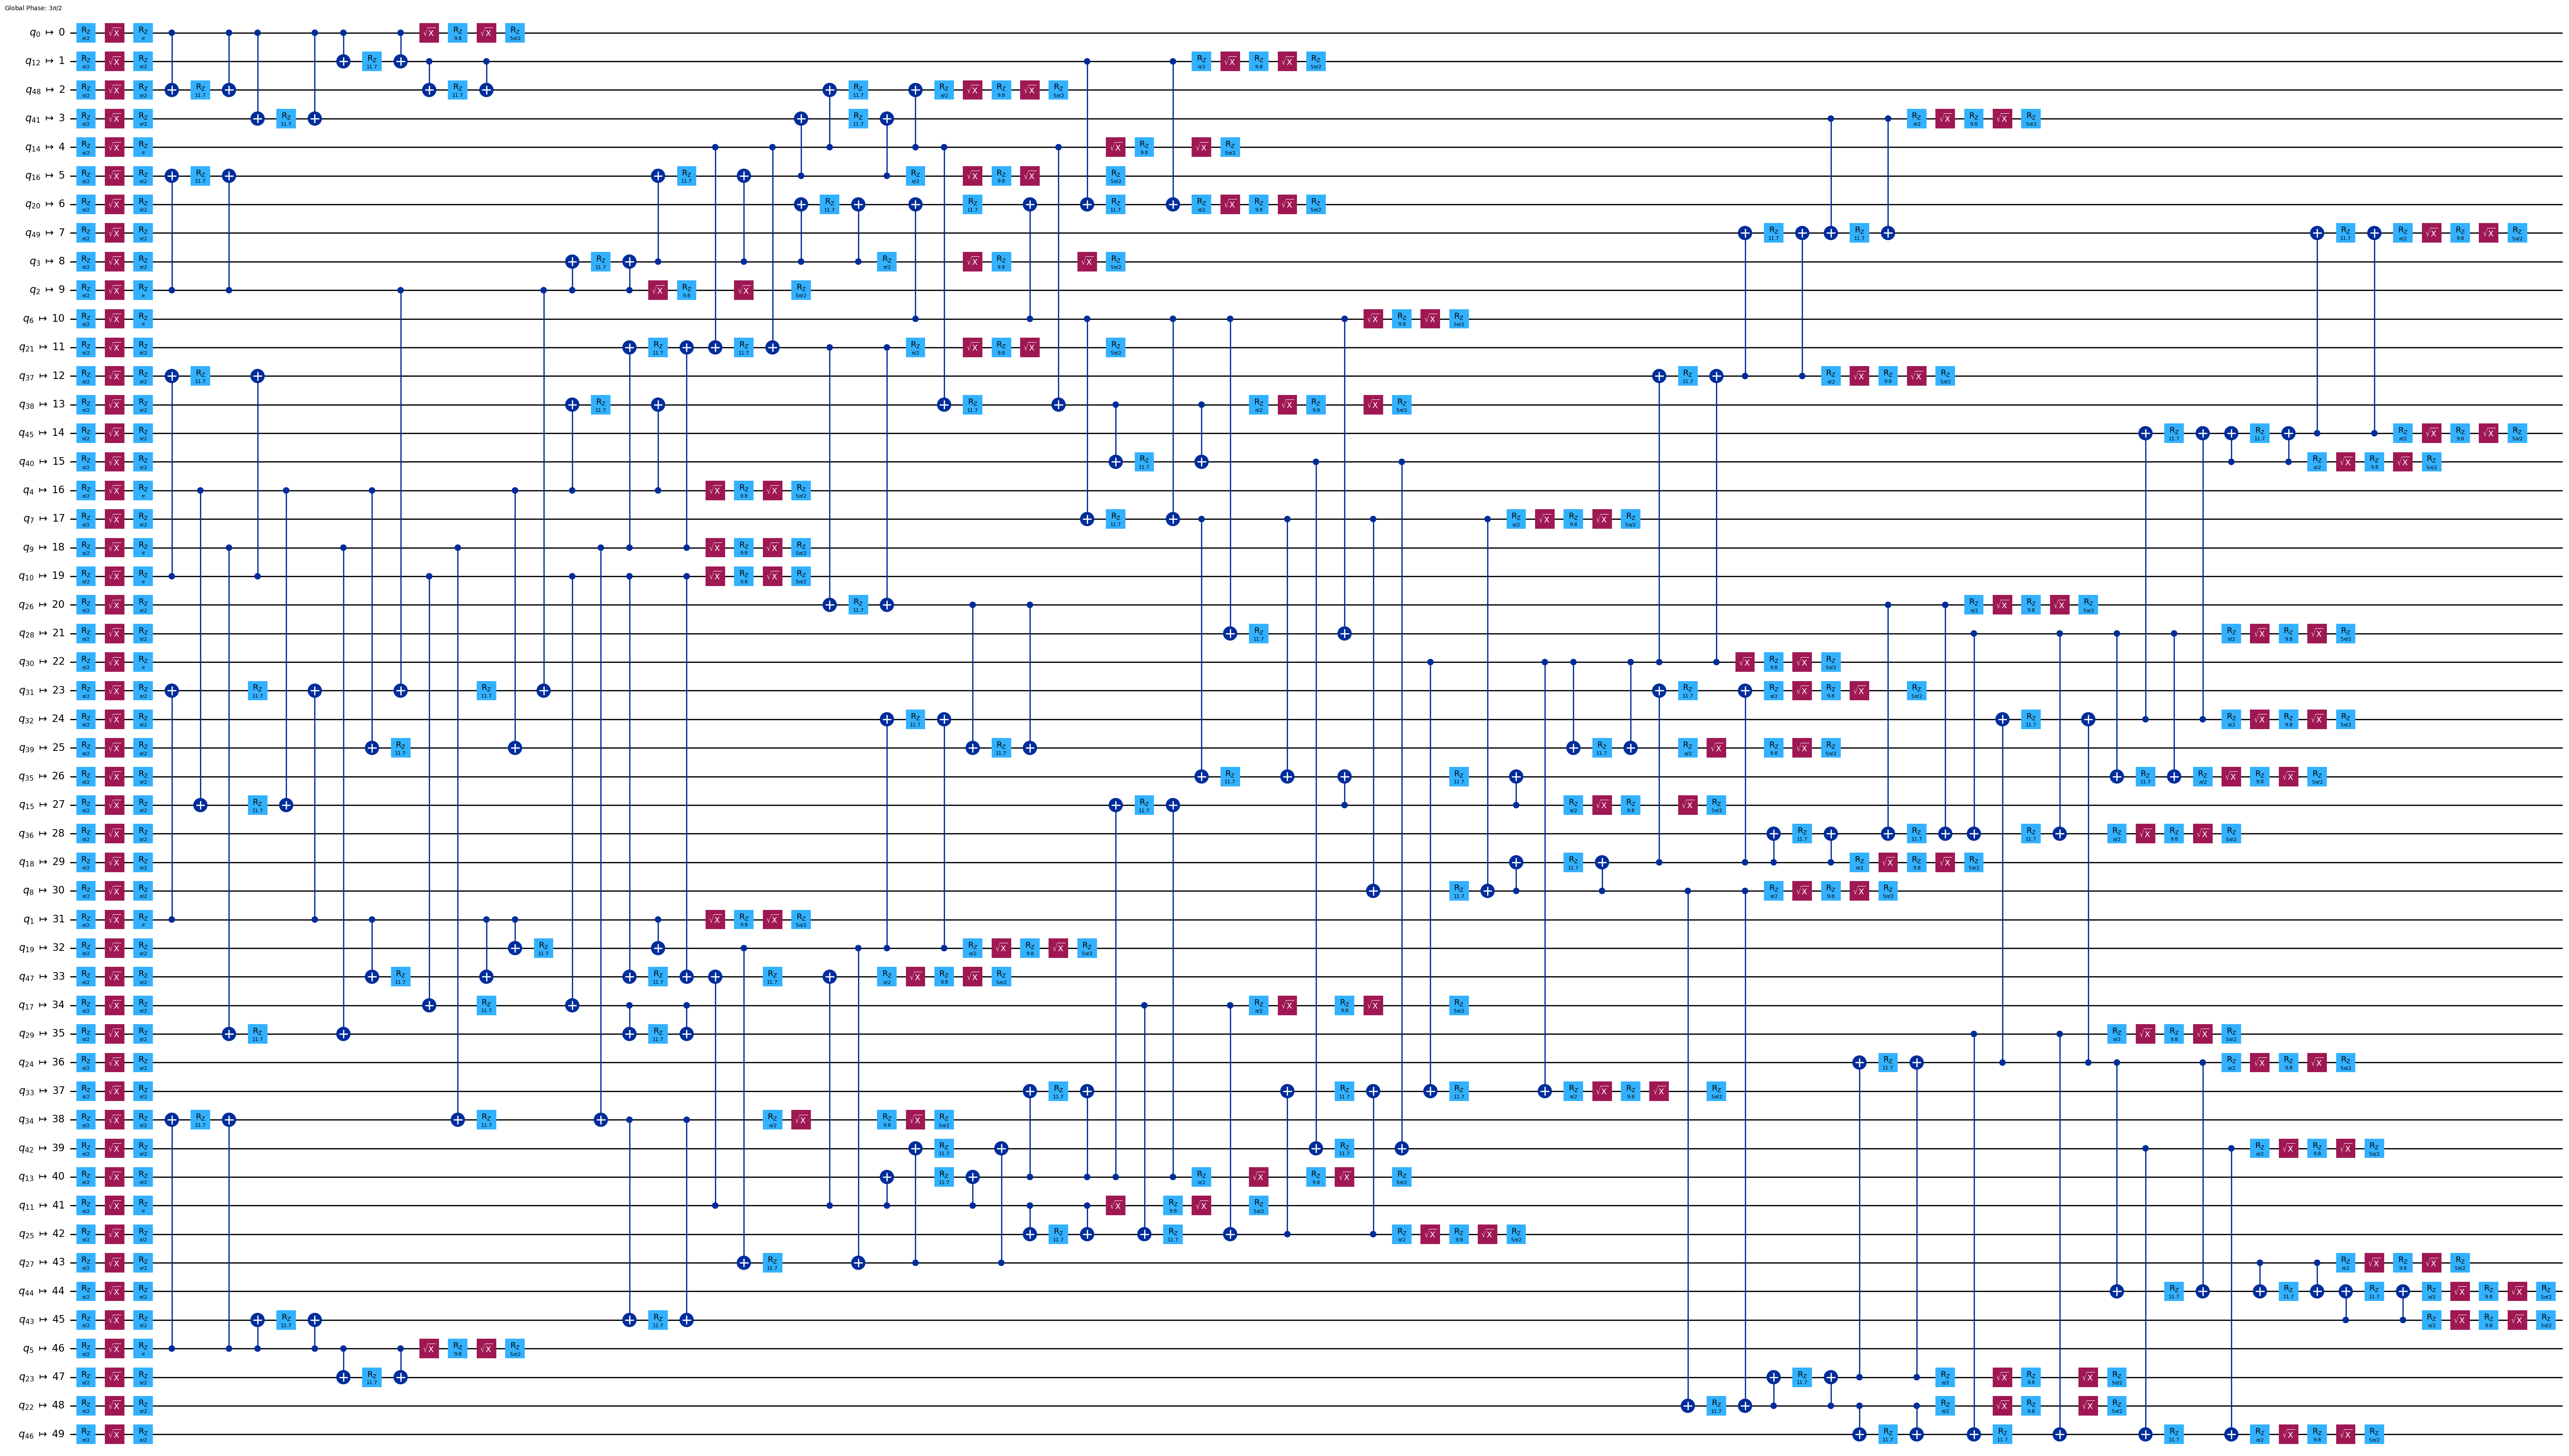

In [9]:
optimized_circuit.draw("mpl", fold=False, idle_wires=False)



ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...
-> Converted! Network has 814 tensors and 964 indices.


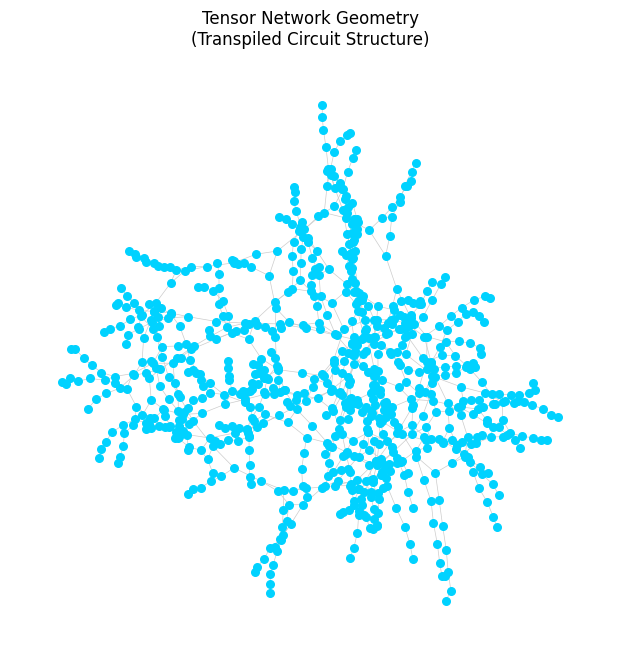


[Step 3] Attempting Naive Contraction...


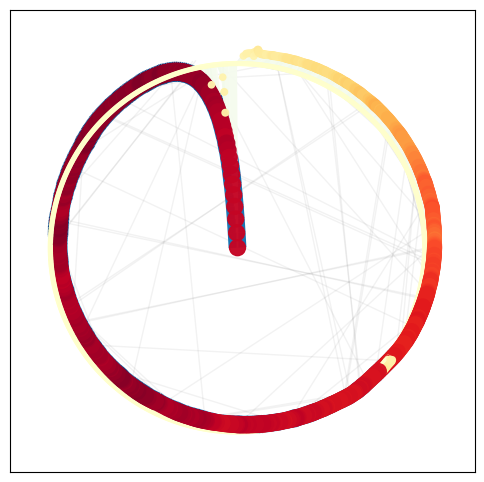

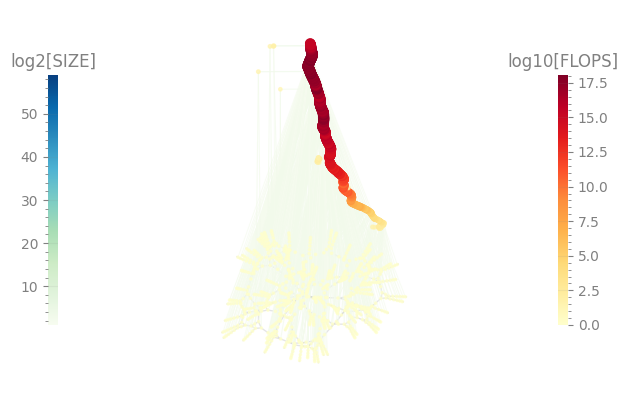


[Step 3B] Attempting CPU Contraction...


F=17.46 C=17.56 S=50.00 P=50.00: 100%|██████████| 64/64 [00:01<00:00, 45.16it/s] 


-> CPU Max Memory: 2^50.0 elements
-> Total Slices (CPU Tasks): 1
-> Calculation Overhead: 1.00x


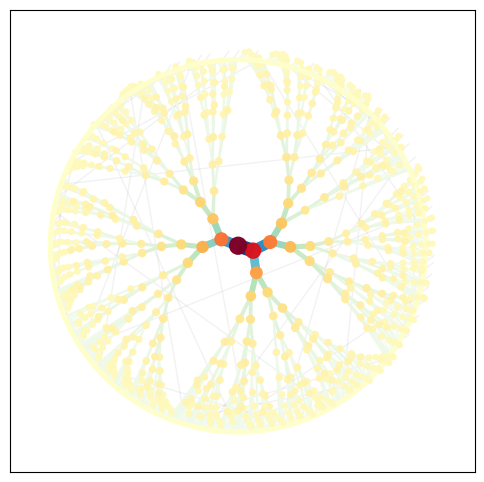

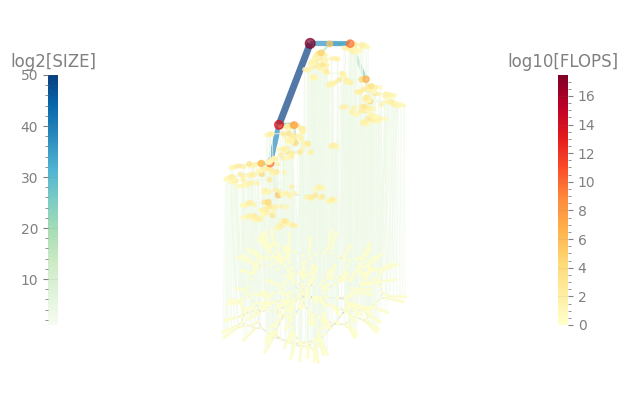


[Step 4B] Optimizing for UPMEM (Limit: 64 MB)...


F=17.47 C=17.60 S=22.00 P=22.39 $=268435456.00: 100%|██████████| 64/64 [01:30<00:00,  1.41s/it]


-> UPMEM Max Memory: 2^22.0 elements
-> Total Slices (DPU Tasks): 268435456
-> Calculation Overhead: 1.00x


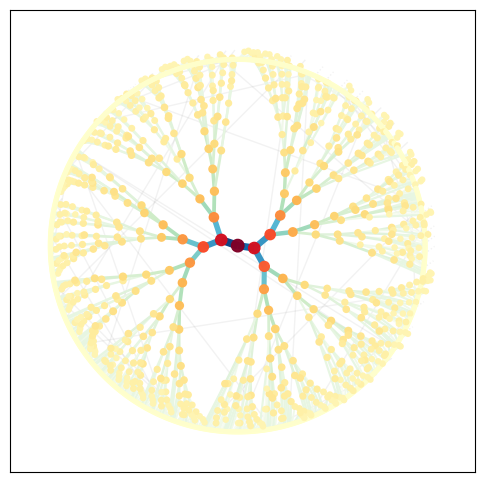

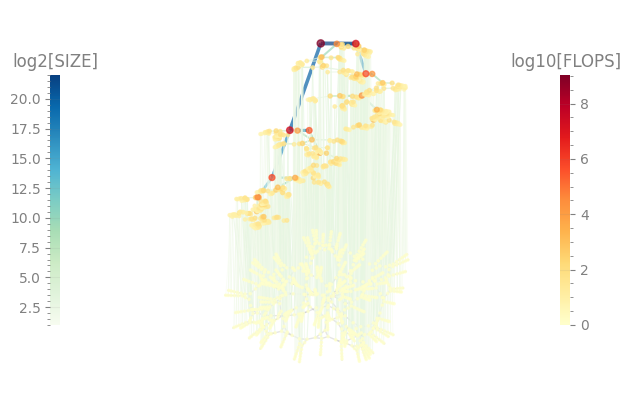

In [11]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices
    print(f"-> Converted! Network has {n_tensors} tensors and {n_indices} indices.")

    # -----------------------------------------------------
    # STEP 2: GEOMETRY VIEW (Physics)
    # -----------------------------------------------------
    G_tn = nx.Graph()
    tensors = [t for t in tn]
    for i in range(len(tensors)):
        G_tn.add_node(i)
        for j in range(i + 1, len(tensors)):
            if set(tensors[i].inds).intersection(tensors[j].inds):
                G_tn.add_edge(i, j)

    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G_tn, seed=42, k=0.15, iterations=50)
    nx.draw(G_tn, pos, node_size=30, node_color='#00d2ff', edge_color='#cccccc', width=0.5)
    plt.title("Tensor Network Geometry\n(Transpiled Circuit Structure)")
    plt.show()

    # -----------------------------------------------------
    # STEP 3A: NAIVE SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3] Attempting Naive Contraction...")
    opt_naive = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_naive = opt_naive.search(inputs, output, size_dict)
        max_mem_naive = math.log2(tree_naive.max_size())
        
        fig, ax = plt.subplots(figsize=(6, 6))
        # --- SAFE PLOT: No edge_alpha ---
        tree_naive.plot_ring(ax=ax)
        tree_naive.plot_tent(order=True)
        ax.set_title(f"Naive Path\nMem: 2^{max_mem_naive:.1f} | Slices: 1")
        plt.show()
    except Exception as e:
        print(f"Naive search failed: {e}")

    # -----------------------------------------------------
    # STEP 3B: CPU SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3B] Attempting CPU Contraction...")
    opt_cpu = ctg.HyperOptimizer(
        methods=['kahypar', 'greedy'],  # Use graph partitioning (requires kahypar) + greedy
        minimize='flops',               # CPU prefers minimizing pure math operations
        max_repeats=64,                # Explore more paths to find the best one
        parallel=True,                  # Use multiple CPU cores to perform the search
        progbar=True
    )
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_cpu = opt_cpu.search(inputs, output, size_dict)
        max_mem_cpu = math.log2(tree_cpu.max_size())
        slices = tree_cpu.nslices
        overhead = tree_cpu.total_flops() / tree_cpu.contract_stats()['flops']
        
        print(f"-> CPU Max Memory: 2^{max_mem_cpu:.1f} elements")
        print(f"-> Total Slices (CPU Tasks): {slices}")
        print(f"-> Calculation Overhead: {overhead:.2f}x")

        
        fig, ax = plt.subplots(figsize=(6, 6))
        # --- SAFE PLOT: No edge_alpha ---
        tree_cpu.plot_ring(ax=ax)
        tree_cpu.plot_tent(order=True)
        ax.set_title(f"CPU Path\nMem: 2^{max_mem_cpu:.1f} | Slices: {slices}")
        plt.show()
    except Exception as e:
        print(f"CPU search failed: {e}")

    # -----------------------------------------------------
    # STEP 4: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    '''limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmem = opt_upmem.search(inputs, output, size_dict)
    
    max_mem_upmem = math.log2(tree_upmem.max_size())
    slices = tree_upmem.nslices
    overhead = tree_upmem.total_flops() / tree_upmem.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmem:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slices}")
    print(f"-> Calculation Overhead: {overhead:.2f}x")

    fig, ax = plt.subplots(figsize=(6, 6))
    # --- SAFE PLOT: No edge_alpha ---
    tree_upmem.plot_ring(ax=ax)
    tree_upmem.plot_tent(order=True)
    #tree_upmem.plot_flat()
    ax.set_title(f"UPMEM Sliced Path\nMem: 2^{max_mem_upmem:.1f} | Slices: {slices}")
    plt.show()'''

    # -----------------------------------------------------
    # STEP 4B: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4B] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmemB = ctg.HyperOptimizer(
        methods=['kahypar', 'greedy'],  # Use graph partitioning (requires kahypar) + greedy
        minimize='combo',               # CPU prefers minimizing pure math operations
        max_repeats=64,                # Explore more paths to find the best one
        parallel=True,                  # Use multiple CPU cores to perform the search
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmemB = opt_upmemB.search(inputs, output, size_dict)
    
    max_mem_upmemB = math.log2(tree_upmemB.max_size())
    slicesB = tree_upmemB.nslices
    overheadB = tree_upmemB.total_flops() / tree_upmemB.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmemB:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slicesB}")
    print(f"-> Calculation Overhead: {overheadB:.2f}x")

    fig, ax = plt.subplots(figsize=(6, 6))
    # --- SAFE PLOT: No edge_alpha ---
    tree_upmemB.plot_ring(ax=ax)
    tree_upmemB.plot_tent(order=True)
    #tree_upmem.plot_flat()
    ax.set_title(f"UPMEM Sliced Path\nMem: 2^{max_mem_upmemB:.1f} | Slices: {slicesB}")
    plt.show()

# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=64)

In [44]:
def plot_bar_flops(tree, output_file="cbar_flops.png"):
    min_step_flops = float('inf')
    max_step_flops = 0

    # Iterate over all intermediate nodes (keys in tree.info)
    for node in tree.info:
        # tree.get_flops(node) returns the cost to form that specific node
        flops = tree.get_flops(node)
        if flops > max_step_flops:
            max_step_flops = flops
        if flops < min_step_flops and flops != 0:
            min_step_flops = flops

    print(f"Max single-step FLOPs: {max_step_flops:.2e}")
    min_val = min_step_flops       # Example: 10^0
    max_val = max_step_flops   # Example: 10^4
    cmap_name = 'YlOrRd' # Yellow-Orange-Red (same as your FLOPS scale)

    # 2. Setup the Figure and Axis
    # Aspect ratio (width, height) controls the "bar" shape
    vmin_log = np.log10(min_val)
    vmax_log = np.log10(max_val)

    # 3. Setup Figure
    fig, ax = plt.subplots(figsize=(1, 6))
    fig.subplots_adjust(right=0.25)

    # 4. Use LINEAR Normalize on the log values
    # This ensures nice, even ticks like 0.0, 1.0, 2.0
    norm = mpl.colors.Normalize(vmin=vmin_log, vmax=vmax_log)
    cmap = plt.get_cmap('plasma_r')

    # 5. Create the Colorbar
    cb = mpl.colorbar.ColorbarBase(ax, 
                                cmap=cmap,
                                norm=norm,
                                orientation='vertical')

    # 6. Labeling to match the style
    #cb.set_label('log10[FLOPS]', size=12, labelpad=10) # The label indicates it's log data
    cb.ax.tick_params(labelsize=10) # Adjust tick size
    fig.savefig(output_file, bbox_inches='tight', dpi=300, transparent=True)
    plt.close(fig)



def plot_bar_size(tree, output_file="cbar_size.png"):
    min_step_size = float('inf')
    max_step_size = 0

    # Iterate over all intermediate nodes
    for node in tree.info:
        # tree.get_size(node) returns the number of elements in the tensor
        size = tree.get_size(node)
        
        if size > max_step_size:
            max_step_size = size
        if size < min_step_size and size > 0:
            min_step_size = size


    # 2. Setup Plotting Variables
    min_val = min_step_size
    max_val = max_step_size

    # Use log2 for memory/size (standard convention)
    vmin_log = np.log2(min_val)
    vmax_log = np.log2(max_val)

    # 3. Setup Figure
    fig, ax = plt.subplots(figsize=(1, 6))
    fig.subplots_adjust(right=0.25)

    # 4. Use LINEAR Normalize on the log2 values
    norm = mpl.colors.Normalize(vmin=vmin_log, vmax=vmax_log)

    # Use 'YlGnBu' (Yellow-Green-Blue) to match standard Cotengra size plots
    cmap = plt.get_cmap('PuBuGn') 

    # 5. Create the Colorbar
    cb = mpl.colorbar.ColorbarBase(ax, 
                                cmap=cmap,
                                norm=norm,
                                orientation='vertical')

    # 6. Labeling
    # labeling it log2[SIZE] to be explicit
    # cb.set_label('log2[SIZE]', size=12, labelpad=10) 
    cb.ax.tick_params(labelsize=10)

    fig.savefig(output_file, bbox_inches='tight', dpi=300, transparent=True)
    plt.close(fig)

def plot_and_save_tree_with_separate_bars(tree, output_file_main="main_plot.png", output_file_flops="cbar_flops.png", output_file_size="cbar_size.png"): 
    plot_bar_flops(tree, output_file_flops)
    plot_bar_size(tree, output_file_size)

    fig, ax = tree.plot_tent(order=True, colorbars=False, edge_colormap="PuBuGn", node_colormap="plasma_r")
    fig.savefig(output_file_main, bbox_inches='tight', dpi=300, transparent=True)

    plt.close(fig)


ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...
-> Converted! Network has 814 tensors and 964 indices.


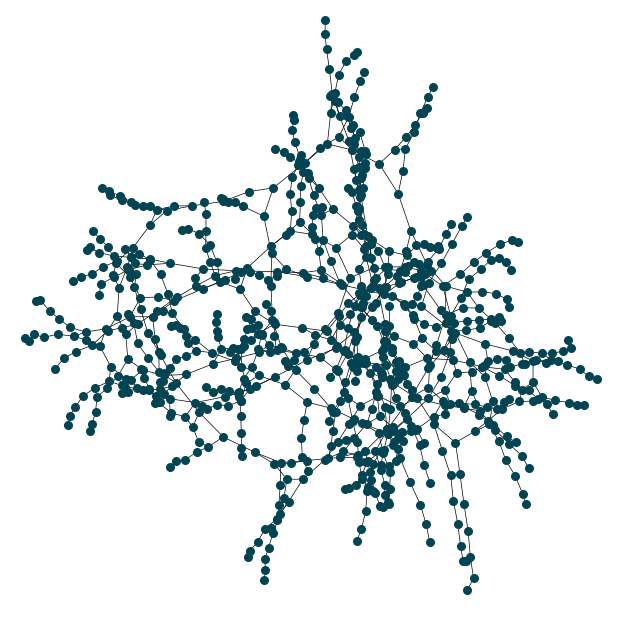


[Step 3] Attempting Naive Contraction...
Max single-step FLOPs: 1.15e+18


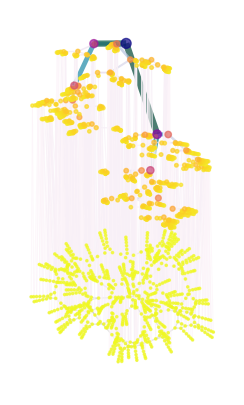

In [45]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices
    print(f"-> Converted! Network has {n_tensors} tensors and {n_indices} indices.")

    # -----------------------------------------------------
    # STEP 2: GEOMETRY VIEW (Physics)
    # -----------------------------------------------------
    G_tn = nx.Graph()
    tensors = [t for t in tn]
    for i in range(len(tensors)):
        G_tn.add_node(i)
        for j in range(i + 1, len(tensors)):
            if set(tensors[i].inds).intersection(tensors[j].inds):
                G_tn.add_edge(i, j)

    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G_tn, seed=42, k=0.15, iterations=50)
    nx.draw(G_tn, pos, node_size=30, node_color="#004453", edge_color="#000000", width=0.5)
    #  nx.draw(G_tn, pos, node_size=30, node_color='#00d2ff', edge_color='#cccccc', width=0.5)
    #plt.title("Tensor Network Geometry\n(Transpiled Circuit Structure)")
    plt.xlim([-1.05, 0.95])
    plt.ylim([-0.62, 0.72])

    plt.savefig("tensor_nerwork_large.svg", bbox_inches='tight', dpi=300, transparent=True )
    plt.show()

    # -----------------------------------------------------
    # STEP 3A: NAIVE SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3] Attempting Naive Contraction...")
    opt_naive = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_naive = opt_naive.search(inputs, output, size_dict)
        plot_and_save_tree_with_separate_bars(tree_naive, "naive_large.svg", "naive_large_flops.svg", "naive_large_size.svg")
    except Exception as e:
        print(f"Naive search failed: {e}")
    
    # -----------------------------------------------------
    # STEP 3B: CPU SIMULATION (Baseline)
    # -----------------------------------------------------
    '''print("\n[Step 3B] Attempting CPU Contraction...")
    opt_cpu = ctg.HyperOptimizer(
        methods=['kahypar', 'greedy'],  # Use graph partitioning (requires kahypar) + greedy
        minimize='flops',               # CPU prefers minimizing pure math operations
        max_repeats=64,                # Explore more paths to find the best one
        parallel=True,                  # Use multiple CPU cores to perform the search
        progbar=True
    )
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_cpu = opt_cpu.search(inputs, output, size_dict)
        max_mem_cpu = math.log2(tree_cpu.max_size())
        slices = tree_cpu.nslices
        overhead = tree_cpu.total_flops() / tree_cpu.contract_stats()['flops']
        
        print(f"-> CPU Max Memory: 2^{max_mem_cpu:.1f} elements")
        print(f"-> Total Slices (CPU Tasks): {slices}")
        print(f"-> Calculation Overhead: {overhead:.2f}x")

        
        fig, ax = plt.subplots(figsize=(6, 6))
        # --- SAFE PLOT: No edge_alpha ---
        tree_cpu.plot_ring(ax=ax)
        tree_cpu.plot_tent(order=True)
        ax.set_title(f"CPU Path\nMem: 2^{max_mem_cpu:.1f} | Slices: {slices}")
        plt.show()
    except Exception as e:
        print(f"CPU search failed: {e}")

    # -----------------------------------------------------
    # STEP 4: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    ''''''limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmem = opt_upmem.search(inputs, output, size_dict)
    
    max_mem_upmem = math.log2(tree_upmem.max_size())
    slices = tree_upmem.nslices
    overhead = tree_upmem.total_flops() / tree_upmem.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmem:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slices}")
    print(f"-> Calculation Overhead: {overhead:.2f}x")

    fig, ax = plt.subplots(figsize=(6, 6))
    # --- SAFE PLOT: No edge_alpha ---
    tree_upmem.plot_ring(ax=ax)
    tree_upmem.plot_tent(order=True)
    #tree_upmem.plot_flat()
    ax.set_title(f"UPMEM Sliced Path\nMem: 2^{max_mem_upmem:.1f} | Slices: {slices}")
    plt.show()'''

    # -----------------------------------------------------
    # STEP 4B: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    '''limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4B] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmemB = ctg.HyperOptimizer(
        methods=['kahypar', 'greedy'],  # Use graph partitioning (requires kahypar) + greedy
        minimize='combo',               # CPU prefers minimizing pure math operations
        max_repeats=64,                # Explore more paths to find the best one
        parallel=True,                  # Use multiple CPU cores to perform the search
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmemB = opt_upmemB.search(inputs, output, size_dict)
    
    max_mem_upmemB = math.log2(tree_upmemB.max_size())
    slicesB = tree_upmemB.nslices
    overheadB = tree_upmemB.total_flops() / tree_upmemB.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmemB:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slicesB}")
    print(f"-> Calculation Overhead: {overheadB:.2f}x")

    plot_and_save_tree_with_separate_bars(tree_upmemB, "upmem_large.svg", "upmem_large_flops.svg", "upmem_large_size.svg")
    '''
# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=64)


ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...
-> Converted! Network has 814 tensors and 964 indices.

[Step 3B] Attempting CPU Contraction...


F=17.16 C=17.33 S=50.00 P=50.00: 100%|██████████| 2048/2048 [00:46<00:00, 44.37it/s] 


-> CPU Max Memory: 2^50.0 elements
-> Total Slices (CPU Tasks): 1
-> Calculation Overhead: 1.00x


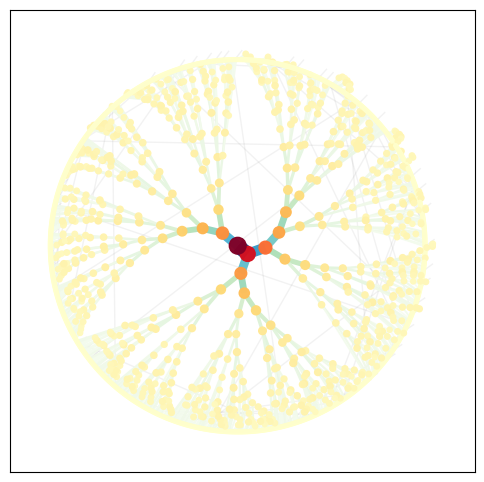

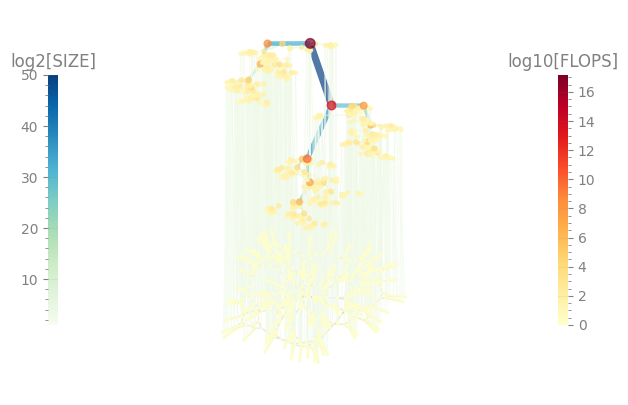

In [11]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices
    print(f"-> Converted! Network has {n_tensors} tensors and {n_indices} indices.")

    # -----------------------------------------------------
    # STEP 3B: CPU SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3B] Attempting CPU Contraction...")
    opt_cpu = ctg.HyperOptimizer(
        methods=['kahypar', 'greedy'],  # Use graph partitioning (requires kahypar) + greedy
        minimize='flops',               # CPU prefers minimizing pure math operations
        max_repeats=2048,                # Explore more paths to find the best one
        parallel=True,                  # Use multiple CPU cores to perform the search
        progbar=True
    )
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_cpu = opt_cpu.search(inputs, output, size_dict)
        max_mem_cpu = math.log2(tree_cpu.max_size())
        slices = tree_cpu.nslices
        overhead = tree_cpu.total_flops() / tree_cpu.contract_stats()['flops']
        
        print(f"-> CPU Max Memory: 2^{max_mem_cpu:.1f} elements")
        print(f"-> Total Slices (CPU Tasks): {slices}")
        print(f"-> Calculation Overhead: {overhead:.2f}x")

        
        fig, ax = plt.subplots(figsize=(6, 6))
        # --- SAFE PLOT: No edge_alpha ---
        tree_cpu.plot_ring(ax=ax)
        tree_cpu.plot_tent(order=True)
        ax.set_title(f"CPU Path\nMem: 2^{max_mem_cpu:.1f} | Slices: {slices}")
        plt.show()
    except Exception as e:
        print(f"CPU search failed: {e}")

# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=64)


VERIFICATION: Calculating Amplitude for |1101010111001010001011001011>
-> Projecting output to bitstring...
-> Standardizing Network (Fixing Hyper-Edges)...

[UPMEM Sliced Result]
Optimizing for 64 MB limit...
Distributing 1 slices to DPUs...
Optimizer Warning: tuple index out of range. Falling back to exact.

FINAL VERIFICATION REPORT
Qiskit Probability:   0.0001
UPMEM Sliced Prob:    8.179703209358798e-07


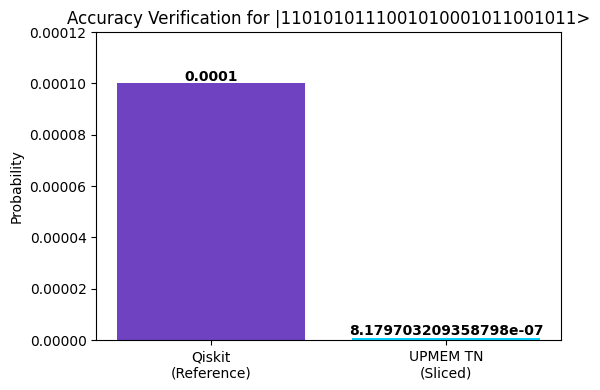

In [22]:
import numpy as np
import math
import cotengra as ctg
import quimb.tensor as qtn
import matplotlib.pyplot as plt

def verify_upmem_calculation(qiskit_circ, target_bitstring, expected_prob, memory_limit_mb=0.002):
    print(f"\n{'='*60}")
    print(f"VERIFICATION: Calculating Amplitude for |{target_bitstring}>")
    print(f"{'='*60}")
    
    # -----------------------------------------------------
    # 1. SETUP TENSOR NETWORK
    # -----------------------------------------------------
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # Robust Manual Gate Conversion
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        if name in ['barrier', 'measure', 'reset']: continue
        try:
            try:
                qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
            except AttributeError:
                qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except:
            pass

    # Extract clean list of tensors
    # This treats the network as a simple pile of tensors, ignoring graph complexity
    tensor_list = list(circ_quimb.psi)
    
    # -----------------------------------------------------
    # 2. PROJECTION (The List Method)
    # -----------------------------------------------------
    print("-> Projecting output to bitstring...")
    
    for i, bit_char in enumerate(target_bitstring):
        ind_name = f'k{i}' 
        bit_val = int(bit_char)
        
        # Create Projection Vector
        state_vector = np.zeros(2, dtype=complex)
        state_vector[bit_val] = 1.0
        T_proj = qtn.Tensor(data=state_vector, inds=(ind_name,))
        
        # Find the tensor connected to this wire
        target_idx = -1
        for idx, t in enumerate(tensor_list):
            if ind_name in t.inds:
                target_idx = idx
                break
        
        if target_idx != -1:
            # Contract locally (Pure Math)
            tensor_list[target_idx] = tensor_list[target_idx] @ T_proj
            
    # Rebuild Network
    tn = qtn.TensorNetwork(tensor_list)
    
    # -----------------------------------------------------
    # 3. STANDARDIZATION (The Fix for ValueError)
    # -----------------------------------------------------
    print("-> Standardizing Network (Fixing Hyper-Edges)...")
    # This inserts "Copy Tensors" so that every wire connects exactly 2 tensors.
    # This prevents the "index appears more than twice" error.
    '''AttributeErrortry:
        tn.expand_hyper_inds(inplace=True)
    except AttributeError:
        # Fallback for older quimb versions
        tn = tn.resolve_hyper_indices()'''
    
    # Check if network is already solved (Scalar)
    if tn.num_tensors <= 1:
        print("-> Network simplified to a scalar! (No Slicing needed)")
        final_amp = tn.contract() if tn.num_tensors == 1 else 1.0
        sliced_prob = abs(final_amp)**2
        print(f"Result: {sliced_prob}")
    else:
        # -----------------------------------------------------
        # 4. RUN UPMEM (SLICED) CONTRACTION
        # -----------------------------------------------------
        inputs = [tuple(t.inds) for t in tn]
        output = () 
        size_dict = {i: d for i, d in tn.ind_sizes().items()}
        
        limit_bytes = memory_limit_mb * 1024 * 1024
        # Safety clamp to prevent 0-byte limits
        if limit_bytes < 256: limit_bytes = 256
        target_log2 = math.log2(limit_bytes / 16) 
        
        print(f"\n[UPMEM Sliced Result]")
        print(f"Optimizing for {memory_limit_mb} MB limit...")
        
        opt_upmem = ctg.HyperOptimizer(
            max_repeats=32, 
            progbar=False,
            slicing_opts={'target_size': 2**target_log2} 
        )
        
        try:
            tree_upmem = opt_upmem.search(inputs, output, size_dict)
            
            # SIMULATE DPUs
            arrays = [t.data for t in tn]
            sliced_amp = 0.0 + 0.0j
            num_slices = tree_upmem.nslices
            
            print(f"Distributing {num_slices} slices to DPUs...")
            
            for i in range(num_slices):
                partial_result = tree_upmem.contract_slice(arrays, i=i)
                sliced_amp += partial_result
                
            sliced_prob = abs(sliced_amp)**2
            print(f"Summed Prob: {sliced_prob}")
            
        except Exception as e:
            print(f"Optimizer Warning: {e}. Falling back to exact.")
            final_amp = tn.contract()
            sliced_prob = abs(final_amp)**2

    # -----------------------------------------------------
    # 5. VISUALIZATION
    # -----------------------------------------------------
    print(f"\n{'='*60}")
    print("FINAL VERIFICATION REPORT")
    print(f"{'='*60}")
    print(f"Qiskit Probability:   {expected_prob}")
    print(f"UPMEM Sliced Prob:    {sliced_prob:}")
    
    labels = ['Qiskit\n(Reference)', 'UPMEM TN\n(Sliced)']
    values = [expected_prob, sliced_prob]
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=['#6f42c1', '#00d2ff'])
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval}", 
                 ha='center', va='bottom', fontweight='bold')
                 
    plt.title(f"Accuracy Verification for |{target_bitstring}>")
    plt.ylabel("Probability")
    plt.ylim(0, max(values) * 1.2)
    plt.show()

# =========================================================
# RUN
# =========================================================
top_bitstring_str = list(final_distribution_bin.keys())[0] 
top_prob = list(final_distribution_bin.values())[0]

# Run Verification
verify_upmem_calculation(
    optimized_circuit, 
    target_bitstring=top_bitstring_str[::-1], 
    expected_prob=top_prob,
    memory_limit_mb=64
)